Found 12 files across all subfolders. Processing individually...
Combined dataset size: (12924, 64)
Plotting Correlation Matrix...


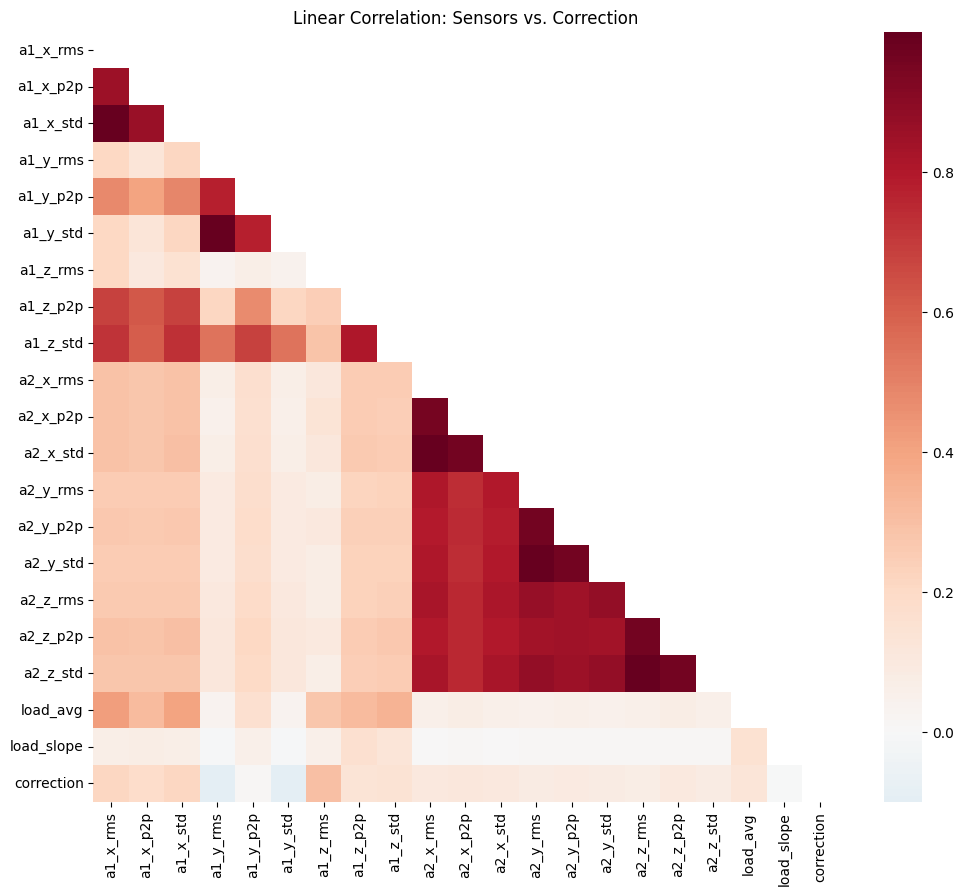


--- Reality Check: What is actually in each set? ---
Classes in Training Set: [0 1 2 3 4]
Classes in Test Set:     [0 1 2 3 4]

Tuning for 5 classes using CatBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

--- Final Model Report ---
              precision    recall  f1-score   support

           0       1.00      0.09      0.16      2688
           1       0.44      0.93      0.59       130
           2       0.00      0.01      0.00       186
           4       0.00      0.00      0.00       135
           5       0.49      0.72      0.58      1005

    accuracy                           0.26      4144
   macro avg       0.39      0.35      0.27      4144
weighted avg       0.78      0.26      0.27      4144



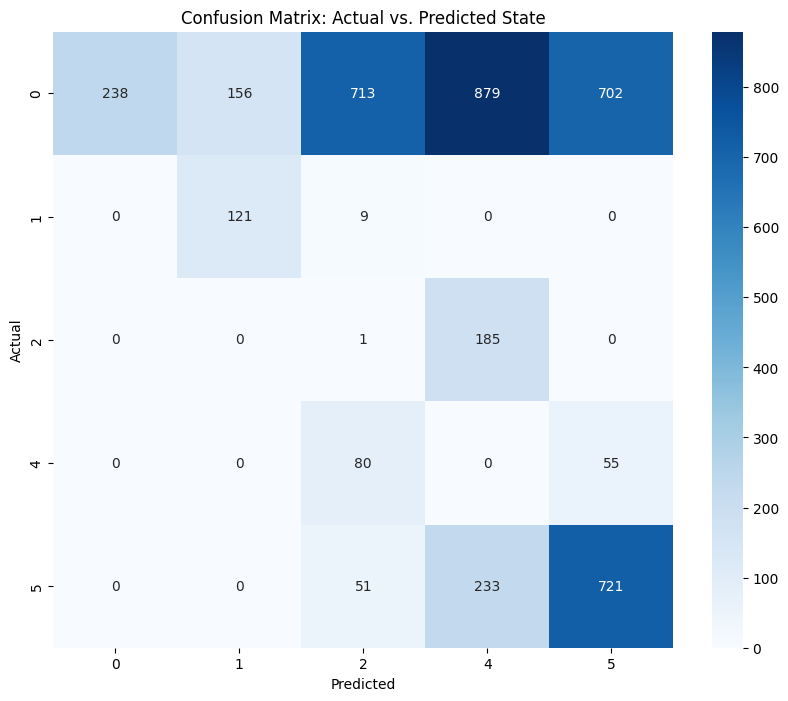

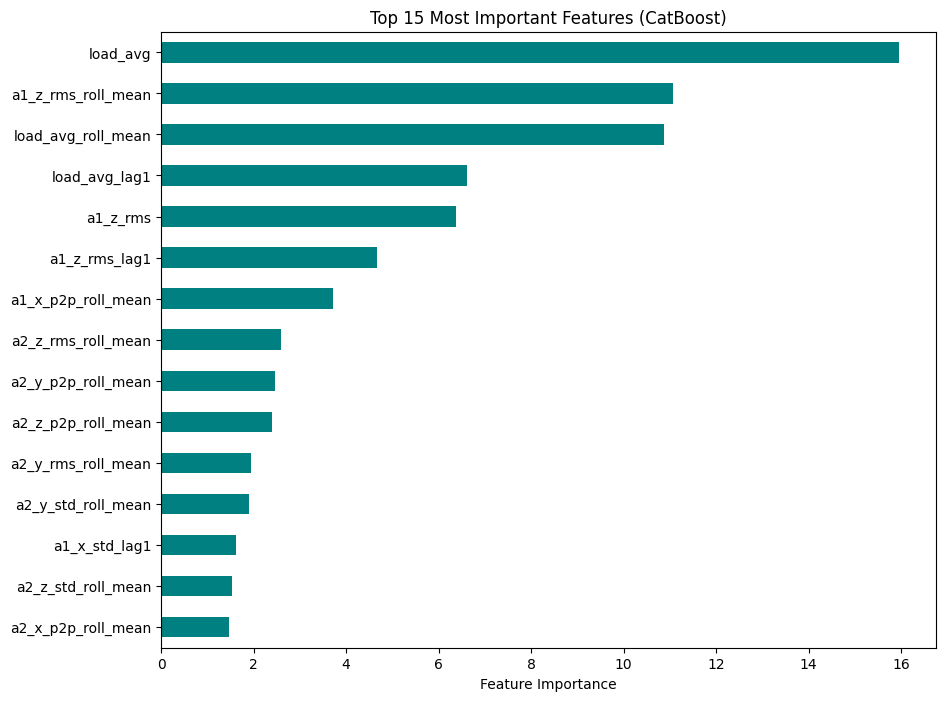


Model saved successfully as catboost_printer_model.cbm
Raw Python inference code saved as catboost_inference.py


In [4]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# --- 1. Data Loading & Individual Processing (Recursive) ---
path = "/home/ubuntu/cleanedData/" 
all_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

if not all_files:
    print(f"Error: No CSV files found in {path} or its subfolders.")
    exit()

li = []
print(f"Found {len(all_files)} files across all subfolders. Processing individually...")

base_sensor_cols = [] 

for file_index, filename in enumerate(all_files):
    temp_df = pd.read_csv(filename)
    
    # Create the file_id column so GroupKFold knows which rows belong to which print!
    temp_df['file_id'] = file_index 
    
    # A. Sort by time so lags make sense
    if 'timestamp' in temp_df.columns:
        temp_df = temp_df.sort_values('timestamp').reset_index(drop=True)
    
    # B. Generate Features (INSIDE the loop prevents data bleed)
    exclude = ['relative_img_path', 'correction', 'timestamp', 'file_id']
    sensor_cols = [col for col in temp_df.columns if col not in exclude]
    
    if not base_sensor_cols:
        base_sensor_cols = sensor_cols # Grab the base column names
    
    new_features = []
    for col in sensor_cols:
        new_features.append(pd.DataFrame({
            f"{col}_lag1": temp_df[col].shift(1),
            f"{col}_roll_mean": temp_df[col].rolling(window=5).mean()
        }, index=temp_df.index))
    
    temp_df = pd.concat([temp_df] + new_features, axis=1)
    
    # C. Drop NaNs now so Print B doesn't see Print A's tail
    li.append(temp_df.dropna())

# Combine everything into one master dataframe
df = pd.concat(li, axis=0, ignore_index=True).copy()
print(f"Combined dataset size: {df.shape}")

# --- 2. Label Encoding ---
df['correction'] = df['correction'].fillna(0).astype(int)
le = LabelEncoder()
df['correction'] = le.fit_transform(df['correction'])
num_classes = len(le.classes_)

# --- 3. Correlation Matrix (Diagnostic) ---
print("Plotting Correlation Matrix...")
plt.figure(figsize=(12, 10))
corr_cols = base_sensor_cols + ['correction']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, annot=False)
plt.title("Linear Correlation: Sensors vs. Correction")
plt.show()

# --- 4. Split and Weights (Stratified & Grouped) ---
X = df.drop(columns=['timestamp', 'relative_img_path', 'correction', 'file_id'], errors='ignore')
y = df['correction']
groups = df['file_id'] # Extract our group tags

# Keep 3 splits so Class 2 has a better chance of surviving the split!
sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

# 1. Get the standard balanced weights first
base_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Apply the Penalty Multiplier
penalty_factor = 10.0 

# 3. Create the final 'weights' array:
# If the class is 0, keep the normal weight. If it's anything else, multiply by 10!
weights = np.where(y_train == 0, base_weights, base_weights * penalty_factor)

print("\n--- Reality Check: What is actually in each set? ---")
print(f"Classes in Training Set: {np.unique(y_train)}")
print(f"Classes in Test Set:     {np.unique(y_test)}")

# --- 5. Hyperparameter Tuning (CATBOOST EDITION) ---
print(f"\nTuning for {num_classes} classes using CatBoost...")

clf = CatBoostClassifier(
    loss_function='MultiClass',
    random_seed=42,
    verbose=False # Keeps the terminal from getting spammed by CatBoost logs
)

# CatBoost uses slightly different parameter names than XGBoost
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200, 300], # equivalent to n_estimators
    'l2_leaf_reg': [1, 3, 5]
}

inner_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

# Using f1_macro to protect against the missing inner-class crash!
search = RandomizedSearchCV(
    clf, param_distributions=param_grid, n_iter=10, 
    scoring='f1_macro', cv=inner_cv, verbose=1, random_state=42
)

fit_params = {'sample_weight': weights}
search.fit(X_train, y_train, groups=groups_train, **fit_params)

# --- 6. Final Model & Evaluation ---
best_model = search.best_estimator_

probs = best_model.predict_proba(X_test)
predictions = np.argmax(probs, axis=1)

print("\n--- Final Model Report ---")
target_names = [str(c) for c in le.classes_]
print(classification_report(y_test, predictions, target_names=target_names, zero_division=0))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Actual vs. Predicted State")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- 7. Feature Importance & Save (CATBOOST EDITION) ---
# CatBoost requires us to plot feature importance slightly differently
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).sort_values().plot(kind='barh', color='teal')
plt.title("Top 15 Most Important Features (CatBoost)")
plt.xlabel("Feature Importance")
plt.show()

# 🟢 Native CatBoost Format
best_model.save_model("catboost_printer_model.cbm")
print("\nModel saved successfully as catboost_printer_model.cbm")

# 🟢 Optional: Export as raw Python code for Zero-Dependency OctoPrint inference!
best_model.save_model("catboost_inference.py", format="python")
print("Raw Python inference code saved as catboost_inference.py")

In [2]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.7/96.7 MB 15.9 MB/s  0:00:06m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 54.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]
Note: you may need to restart the kernel to use updated packages.


Found 15 files. Building CatBoost dataset...

Training CatBoost model...
0:	learn: 1.3192516	total: 62ms	remaining: 30.9s
100:	learn: 0.1185378	total: 4.82s	remaining: 19s
200:	learn: 0.0935076	total: 9.35s	remaining: 13.9s
300:	learn: 0.0795485	total: 13.9s	remaining: 9.16s
400:	learn: 0.0683769	total: 18.3s	remaining: 4.53s
499:	learn: 0.0616110	total: 22.8s	remaining: 0us

--- CatBoost Model Report ---
              precision    recall  f1-score   support

           0       0.54      0.89      0.67      1256
           1       0.71      0.58      0.64       130
           2       0.44      0.26      0.33       189
           3       0.72      1.00      0.84       158
           5       0.91      0.22      0.36      1014

    accuracy                           0.59      2747
   macro avg       0.67      0.59      0.57      2747
weighted avg       0.69      0.59      0.54      2747



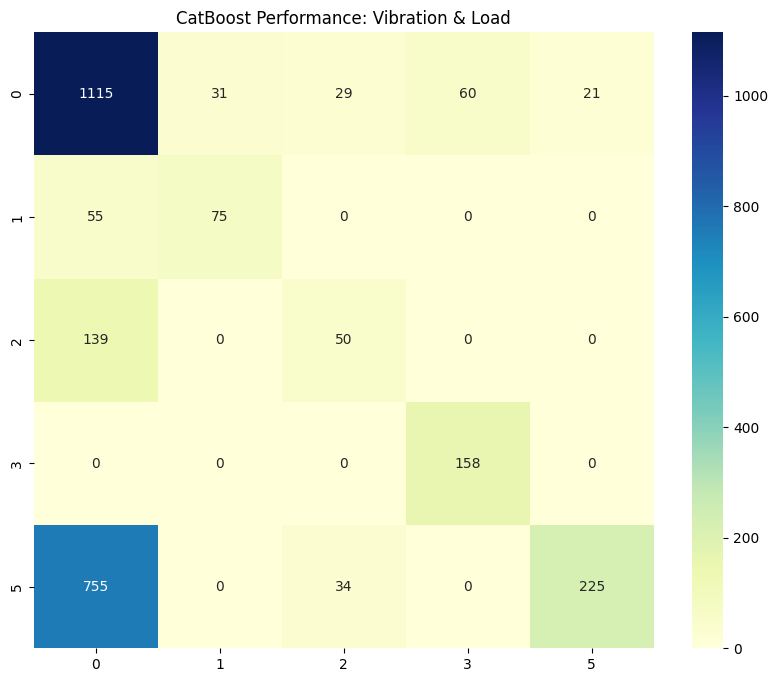


Model saved as catboost_vibration_model.cbm


In [5]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# --- 1. Data Loading & Vibration Feature Engineering ---
path = "/home/ubuntu/cleanedData/" 
all_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

if not all_files:
    print(f"Error: No CSV files found in {path}.")
    exit()

li = []
print(f"Found {len(all_files)} files. Building CatBoost dataset...")

for file_index, filename in enumerate(all_files):
    temp_df = pd.read_csv(filename)
    temp_df['file_id'] = file_index 
    
    if 'timestamp' in temp_df.columns:
        temp_df = temp_df.sort_values('timestamp').reset_index(drop=True)
    
    exclude = ['relative_img_path', 'correction', 'timestamp', 'file_id']
    sensor_cols = [col for col in temp_df.columns if col not in exclude]
    
    new_features = []
    for col in sensor_cols:
        new_features.append(pd.DataFrame({
            f"{col}_roll_mean": temp_df[col].rolling(window=15).mean(),
            f"{col}_roll_std": temp_df[col].rolling(window=15).std(),
            f"{col}_vibe_delta": temp_df[col].diff()
        }, index=temp_df.index))
    
    temp_df = pd.concat([temp_df] + new_features, axis=1)
    temp_df = temp_df.bfill().ffill() # Handle NaNs
    li.append(temp_df)

df = pd.concat(li, axis=0, ignore_index=True).copy()

# --- 2. Class Pruning & Undersampling ---
# Keep: 0, 1, 2, 3, 5 | Drop: 4
df = df[df['correction'] != 4] 

# Undersample Class 0 (Normal) to balance the load
df_normal = df[df['correction'] == 0]
df_errors = df[df['correction'] != 0]
df_normal_shrunk = df_normal.sample(frac=0.4, random_state=42)
df = pd.concat([df_normal_shrunk, df_errors], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# --- 3. Encoding ---
le = LabelEncoder()
df['correction'] = le.fit_transform(df['correction'].fillna(0).astype(int))
num_classes = len(le.classes_)

# --- 4. Splitting (Group-based to prevent leaking print data) ---
X = df.drop(columns=['timestamp', 'relative_img_path', 'correction', 'file_id'], errors='ignore')
y = df['correction']
groups = df['file_id']

sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# --- 5. CatBoost Class Weights ---
# Calculate weights manually to help the "ignored" classes (1, 2, 5)
class_counts = y_train.value_counts().to_dict()
total_samples = len(y_train)
# Weight formula: total / (num_classes * class_count)
# Then we add a "boost" factor to error classes
weights = {cls: (total_samples / (num_classes * count)) for cls, count in class_counts.items()}
for cls in weights:
    if cls != 0: # If it's an error class, give it a 3x extra push
        weights[cls] *= 3.0

# Convert to list for CatBoost
cb_weights = [weights[i] for i in range(num_classes)]

# --- 6. Training CatBoost ---
print("\nTraining CatBoost model...")

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    class_weights=cb_weights,
    random_seed=42,
    verbose=100, # Show progress every 100 iterations
    thread_count=-1 # Use all CPU cores
)

model.fit(X_train, y_train)

# --- 7. Evaluation ---
predictions = model.predict(X_test)

print("\n--- CatBoost Model Report ---")
target_names = [str(c) for c in le.classes_]
print(classification_report(y_test, predictions, target_names=target_names))

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=target_names, yticklabels=target_names)
plt.title("CatBoost Performance: Vibration & Load")
plt.show()

# Save for Pi 5 Deployment
model.save_model("catboost_vibration_model.cbm")
print("\nModel saved as catboost_vibration_model.cbm")